# Analyse HSIC-ANOVA hiérarchique sur sorties MAELIA réelles

Ce notebook applique la méthode HSIC-ANOVA hiérarchique aux sorties réellement produites par MAELIA.

La logique est la suivante :

- normalisation des variables continues ;
- apprentissage d'une Random Forest par sortie ;
- importance par permutation pour construire les échelles de noyaux `theta` ;
- appel à `hsic_anova_hierarchical` avec les variables actives/inactives du plan hiérarchique.

Note pratique : HSIC construit des matrices de distance en `n × n`. Pour éviter une explosion mémoire sur 10 000 simulations, le notebook contient un paramètre `HSIC_MAX_SAMPLES`.

## 1. Imports, chemins et paramètres

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

warnings.filterwarnings('ignore')

def find_project_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'requirements.txt').exists() and (candidate / 'maelia_sa_pipeline').exists():
            return candidate
    raise RuntimeError('Racine du dépôt introuvable depuis le répertoire courant.')

PROJECT_ROOT = find_project_root()
ANALYSIS_DIR = PROJECT_ROOT / 'analysis'
TOOLS_DIR = ANALYSIS_DIR / 'tools'
OUTPUT_DIR = ANALYSIS_DIR / 'hsic_anova_results'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(TOOLS_DIR))

from hsic_methods import hsic_anova_hierarchical

OUTPUT_COLS = ['N_lixi', 'dCorg', 'rdt']
DATASET_FILENAME = 'dataset_metamodel.csv'
DATASET_CANDIDATES = [
    PROJECT_ROOT / 'simulations' / 'log_terrainSA',
    ANALYSIS_DIR / DATASET_FILENAME,
]

RANDOM_SEED = 43
RF_N_ESTIMATORS = 200
RF_MAX_DEPTH = 10
RF_MIN_SAMPLES_LEAF = 15
PERMUTATION_REPEATS = 10
THETA_SCALE = 5.0
THETA_IMPORTANCE_THRESHOLD = 0.005
HSIC_MAX_ORDER = 4

# Mettre None pour utiliser tous les points. Attention : coût mémoire en O(n² × p).
HSIC_MAX_SAMPLES = 5000

print(f'Projet : {PROJECT_ROOT}')
print(f'Outils HSIC : {TOOLS_DIR}')
print(f'Sorties : {OUTPUT_DIR}')


Projet : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA
Outils HSIC : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/tools
Sorties : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results


## 2. Chargement du dataset réel MAELIA

In [2]:
def resolve_dataset_path(candidates, filename=DATASET_FILENAME):
    checked = []
    for candidate in candidates:
        candidate = Path(candidate).expanduser()
        checked.append(candidate)

        if candidate.is_file():
            return candidate, checked

        if candidate.is_dir():
            direct_csv = candidate / filename
            checked.append(direct_csv)
            if direct_csv.is_file():
                return direct_csv, checked

            nested = sorted(candidate.rglob(filename))
            checked.extend(nested[:5])
            if nested:
                return nested[0], checked

    return None, checked


DATASET_PATH, checked_dataset_paths = resolve_dataset_path(DATASET_CANDIDATES)

if DATASET_PATH is None:
    print('Aucun dataset terrainSA trouvé. Chemins testés :')
    for candidate in checked_dataset_paths:
        print(' -', candidate)
    raise FileNotFoundError(
        'Exécuter le notebook de simulation terrainSA jusqu’à export de dataset_metamodel.csv, '
        'ou renseigner DATASET_CANDIDATES avec le dossier contenant ce fichier.'
    )

df_raw = pd.read_csv(DATASET_PATH)
print('Dataset chargé :', DATASET_PATH)
print('Dimensions :', df_raw.shape)
display(df_raw.head())

EXPECTED_N_FEATURES = 15
feat_cols = [f'feat_{i}' for i in range(EXPECTED_N_FEATURES)]
missing_features = [col for col in feat_cols if col not in df_raw.columns]
missing_outputs = [col for col in OUTPUT_COLS if col not in df_raw.columns]

if missing_features:
    raise ValueError(
        'Le dataset doit contenir les colonnes feat_* du plan SMT courant. '
        f'Colonnes manquantes : {missing_features}'
    )
if missing_outputs:
    raise ValueError(f'Sorties MAELIA absentes du dataset : {missing_outputs}')


Dataset chargé : /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/simulations/log_terrainSA/dataset_metamodel.csv
Dimensions : (10000, 22)


,feat_0,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,...,feat_12,feat_13,feat_14,Milieu (Climat),Milieu (Sol),N_lixi,dCorg,rdt,point_idx,parcelle
0,0,0,0,53.0,-20.0,1.4,15.0,10.0,259.0,383.0,...,55.0,55.0,55.0,0,0,1.463684,-135.538947,5.541111,0,beauce_5_sa_000
1,0,0,0,87.0,-20.0,3.3,15.0,10.0,259.0,383.0,...,55.0,55.0,55.0,0,0,1.896842,-151.593684,5.316667,1,beauce_5_sa_001
2,0,0,0,52.0,-20.0,2.4,15.0,10.0,259.0,383.0,...,55.0,55.0,55.0,0,0,1.460000,-125.632105,5.362222,2,beauce_5_sa_002
3,2,1,0,58.0,-17.0,3.4,20.6,10.0,317.0,318.0,...,12.2,35.7,55.0,0,0,3.567895,-73.371053,7.044444,3,beauce_5_sa_003
4,1,0,0,75.0,-20.0,1.2,15.0,10.0,114.0,383.0,...,47.4,55.0,55.0,0,0,4.590526,-160.692632,7.616667,4,beauce_5_sa_004


## 3. Reconstruction des 15 paramètres agricoles

In [3]:
AGRI_FEATURES = [
    'n_ferti', 'nb_prepa',
    'Date_Semis', 'Delta_PREPA_Semis', 'Profondeur_Semis',
    'Profondeur_Prepa_1', 'Profondeur_Prepa_2',
    'Date_F1', 'Date_F2', 'Date_F3', 'Date_Recolte',
    'Dose_F1', 'Dose_F2', 'Dose_F3',
]

# Canonical English names used in figures and scientific communication.
# Raw names are kept above to remain compatible with existing terrainSA datasets.
FEATURE_DISPLAY_NAMES = {
        'n_ferti': 'Number_Of_Fertilisations',
    'nb_prepa': 'Number_Of_Preparations',
    'Profondeur_Prepa_1': 'First_Tillage_Depth',
    'Profondeur_Prepa_2': 'Second_Tillage_Depth',
    'Delta_PREPA_Semis': 'Preparation_To_Sowing_Delay',
    'Date_Semis': 'Sowing_Date',
    'Profondeur_Semis': 'Sowing_Depth',
    'Date_Recolte': 'Harvest_Date',
    'Date_F1': 'First_Fertilisation_Date',
    'Dose_F1': 'First_Fertilisation_Dose',
    'Date_F2': 'Second_Fertilisation_Date',
    'Dose_F2': 'Second_Fertilisation_Dose',
    'Date_F3': 'Third_Fertilisation_Date',
    'Dose_F3': 'Third_Fertilisation_Dose',
}

OUTPUT_DISPLAY_NAMES = {
    'N_lixi': 'Nitrogen leaching',
    'dCorg': 'Soil organic carbon change',
    'rdt': 'Yield',
}

AGRI_CATEGORICAL = ['n_ferti', 'nb_prepa']
AGRI_CONTINUOUS = [feature for feature in AGRI_FEATURES if feature not in AGRI_CATEGORICAL]

feat_cols = [f'feat_{i}' for i in range(len(AGRI_FEATURES))]
X_params = df_raw[feat_cols].copy()
X_params.columns = AGRI_FEATURES
for col in AGRI_FEATURES:
    X_params[col] = pd.to_numeric(X_params[col], errors='coerce')

Y_outputs = df_raw[OUTPUT_COLS].copy()
for col in OUTPUT_COLS:
    Y_outputs[col] = pd.to_numeric(Y_outputs[col], errors='coerce')

df = pd.concat([X_params, Y_outputs], axis=1).dropna(subset=OUTPUT_COLS).reset_index(drop=True)
print('Number of usable rows:', len(df))
print('Agricultural parameters:', len(AGRI_FEATURES))
print('Outputs:', [OUTPUT_DISPLAY_NAMES.get(name, name) for name in OUTPUT_COLS])
display(df[AGRI_FEATURES + OUTPUT_COLS].head())


Number of usable rows: 10000
Agricultural parameters: 15
Outputs: ['Nitrogen leaching', 'Soil organic carbon change', 'Yield']


,n_ferti,has_prepa,nb_prepa,Date_Semis,Delta_PREPA_Semis,Profondeur_Semis,Profondeur_Prepa_1,Profondeur_Prepa_2,Date_F1,Date_F2,Date_F3,Date_Recolte,Dose_F1,Dose_F2,Dose_F3,N_lixi,dCorg,rdt
0,0,0,0,53.0,-20.0,1.4,15.0,10.0,259.0,383.0,393.0,334.0,55.0,55.0,55.0,1.463684,-135.538947,5.541111
1,0,0,0,87.0,-20.0,3.3,15.0,10.0,259.0,383.0,393.0,9.0,55.0,55.0,55.0,1.896842,-151.593684,5.316667
2,0,0,0,52.0,-20.0,2.4,15.0,10.0,259.0,383.0,393.0,336.0,55.0,55.0,55.0,1.460000,-125.632105,5.362222
3,2,1,0,58.0,-17.0,3.4,20.6,10.0,317.0,318.0,393.0,342.0,12.2,35.7,55.0,3.567895,-73.371053,7.044444
4,1,0,0,75.0,-20.0,1.2,15.0,10.0,114.0,383.0,393.0,16.0,47.4,55.0,55.0,4.590526,-160.692632,7.616667


## 4. Variables actives/inactives du plan hiérarchique

La méthode HSIC doit savoir si une variable est active pour chaque simulation. Ici, cette information est reconstruite depuis la logique du plan SMT réellement utilisé : par exemple `Date_F2` et `Dose_F2` ne sont actives que si `n_ferti >= 2`, et `Profondeur_Prepa_2` n'est active que lorsqu'une préparation du sol avec deux opérations est décrétée.

In [4]:
FEATURE_INDEX = {name: i for i, name in enumerate(AGRI_FEATURES)}

CONDITIONALLY_ACTING = ['nb_prepa', 'Delta_PREPA_Semis', 'Profondeur_Prepa_1', 'Profondeur_Prepa_2', 'Date_F1', 'Dose_F1', 'Date_F2', 'Dose_F2', 'Date_F3', 'Dose_F3']

num_is_decreed = np.array([feature in CONDITIONALLY_ACTING for feature in AGRI_FEATURES], dtype=bool)
is_categorical = np.array([feature in AGRI_CATEGORICAL for feature in AGRI_FEATURES], dtype=bool)


def build_acting_matrix(X_df):
    acting = np.ones((len(X_df), len(AGRI_FEATURES)), dtype=bool)

    n_ferti = X_df['n_ferti'].to_numpy()
    nb_prepa = X_df['nb_prepa'].to_numpy()

    def set_active(feature, mask):
        acting[:, FEATURE_INDEX[feature]] = mask

    for feature in ['Delta_PREPA_Semis', 'Profondeur_Prepa_1']:
        set_active(feature, nb_prepa >= 1)
    set_active('Profondeur_Prepa_2', nb_prepa >= 2)

    for feature in ['Date_F1', 'Dose_F1']:
        set_active(feature, n_ferti >= 1)
    for feature in ['Date_F2', 'Dose_F2']:
        set_active(feature, n_ferti >= 2)
    for feature in ['Date_F3', 'Dose_F3']:
        set_active(feature, n_ferti >= 3)

    return acting


x_is_acting_full = build_acting_matrix(df[AGRI_FEATURES])
acting_summary = pd.DataFrame({
    'variable': AGRI_FEATURES,
    'conditionnelle': num_is_decreed,
    'categorielle': is_categorical,
    'frequence_active': x_is_acting_full.mean(axis=0),
})
display(acting_summary)
acting_summary.to_csv(OUTPUT_DIR / 'hsic_variable_acting_summary.csv', index=False)


,variable,conditionnelle,categorielle,frequence_active
0,n_ferti,False,True,1.0000
1,has_prepa,False,True,1.0000
2,nb_prepa,True,True,0.5015
3,Date_Semis,False,False,1.0000
4,Delta_PREPA_Semis,True,False,0.5015
5,Profondeur_Semis,False,False,1.0000
6,Profondeur_Prepa_1,True,False,0.5015
7,Profondeur_Prepa_2,True,False,0.2519
8,Date_F1,True,False,0.7527
9,Date_F2,True,False,0.4976


## 5. Normalisation numérique

Les variables continues sont ramenées dans `[0, 1]` sur les bornes observées dans le dataset réel. Les variables catégorielles restent sous leur codage entier, car `hsic_methods.py` leur applique une distance d'égalité/différence.

In [5]:
X_numeric_full = df[AGRI_FEATURES].copy()

for col in AGRI_FEATURES:
    X_numeric_full[col] = pd.to_numeric(X_numeric_full[col], errors='coerce')

for col in AGRI_CATEGORICAL:
    X_numeric_full[col] = X_numeric_full[col].fillna(0).round().astype(float)

# Pour les catégorielles conditionnelles, on force une modalité inactive dédiée.
# Sinon une variable inactive codée 0 pourrait être confondue avec une vraie modalité active 0.
for col in AGRI_CATEGORICAL:
    idx = FEATURE_INDEX[col]
    if num_is_decreed[idx]:
        X_numeric_full.loc[~x_is_acting_full[:, idx], col] = -1.0

for col in AGRI_CONTINUOUS:
    values = X_numeric_full[col].astype(float)
    fill_value = values.median()
    values = values.fillna(fill_value)
    vmin = values.min()
    vmax = values.max()
    if np.isfinite(vmin) and np.isfinite(vmax) and vmax > vmin:
        X_numeric_full[col] = (values - vmin) / (vmax - vmin)
    else:
        X_numeric_full[col] = 0.0

X_numeric_full = X_numeric_full.to_numpy(dtype=float)
print('Matrice X normalisée :', X_numeric_full.shape)


Matrice X normalisée : (10000, 15)


## 6. Sous-échantillon HSIC reproductible

La Random Forest est entraînée sur toutes les lignes disponibles. Le calcul HSIC peut ensuite être réalisé sur un sous-échantillon reproductible pour rester compatible avec la mémoire disponible.

In [6]:
rng = np.random.default_rng(RANDOM_SEED)
n_total = len(df)

if HSIC_MAX_SAMPLES is None or HSIC_MAX_SAMPLES >= n_total:
    hsic_idx = np.arange(n_total)
else:
    hsic_idx = np.sort(rng.choice(n_total, size=HSIC_MAX_SAMPLES, replace=False))

X_hsic = X_numeric_full[hsic_idx]
x_is_acting_hsic = x_is_acting_full[hsic_idx]

print(f'Points disponibles : {n_total}')
print(f'Points utilisés pour HSIC : {len(hsic_idx)}')
pd.Series(hsic_idx, name='row_index').to_csv(OUTPUT_DIR / 'hsic_sample_indices.csv', index=False)


Points disponibles : 10000
Points utilisés pour HSIC : 5000


## 7. Random Forest supervisée et HSIC-ANOVA par sortie

In [7]:
all_importance_tables = []
all_hsic_tables = []
summary_rows = []

for output in OUTPUT_COLS:
    print()
    print('=' * 90)
    print(f'Sortie MAELIA : {output}')
    print('=' * 90)

    y_full = df[output].to_numpy(dtype=float)
    y_hsic = y_full[hsic_idx]

    rf = RandomForestRegressor(
        n_estimators=RF_N_ESTIMATORS,
        max_depth=RF_MAX_DEPTH,
        min_samples_leaf=RF_MIN_SAMPLES_LEAF,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    rf.fit(X_numeric_full, y_full)

    result = permutation_importance(
        rf,
        X_numeric_full,
        y_full,
        n_repeats=PERMUTATION_REPEATS,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )

    theta = result.importances_mean * THETA_SCALE
    theta[result.importances_mean < THETA_IMPORTANCE_THRESHOLD] = 0.0

    importance_df = pd.DataFrame({
        'sortie': output,
        'variable': AGRI_FEATURES,
        'importance_moyenne': result.importances_mean,
        'importance_ecart_type': result.importances_std,
        'theta': theta,
        'conditionnelle': num_is_decreed,
        'categorielle': is_categorical,
        'frequence_active': x_is_acting_full.mean(axis=0),
    }).sort_values('importance_moyenne', ascending=False)
    all_importance_tables.append(importance_df)
    display(importance_df.head(12))

    filtered_results, global_hsic = hsic_anova_hierarchical(
        X=X_hsic,
        Y=y_hsic,
        x_is_acting=x_is_acting_hsic,
        num_is_decreed=num_is_decreed,
        is_categorical=is_categorical,
        theta_scales=theta,
        var_names=AGRI_FEATURES,
        max_order=HSIC_MAX_ORDER,
        use_smt_theta=True,
        use_kta=False,
    )

    hsic_df = pd.DataFrame(filtered_results)
    if not hsic_df.empty:
        hsic_df['sortie'] = output
        hsic_df['variables'] = hsic_df['combo'].apply(
            lambda combo: ' & '.join(AGRI_FEATURES[i] for i in combo)
        )
        hsic_df['global_var_pct'] = 100 * hsic_df['trace'] / global_hsic if global_hsic != 0 else np.nan
        adj_sum = hsic_df['adj_trace'].sum()
        hsic_df['intrinsic_var_pct'] = 100 * hsic_df['adj_trace'] / adj_sum if adj_sum != 0 else np.nan
        hsic_df = hsic_df[
            ['sortie', 'order', 'variables', 'global_var_pct', 'intrinsic_var_pct', 'p_A', 'trace', 'adj_trace']
        ]
    else:
        hsic_df = pd.DataFrame(columns=[
            'sortie', 'order', 'variables', 'global_var_pct', 'intrinsic_var_pct', 'p_A', 'trace', 'adj_trace'
        ])

    all_hsic_tables.append(hsic_df)
    display(hsic_df.head(20))

    summary_rows.append({
        'sortie': output,
        'n_total': n_total,
        'n_hsic': len(hsic_idx),
        'global_hsic': global_hsic,
        'n_terms_kept': len(hsic_df),
        'rf_importance_sum': float(np.nansum(result.importances_mean)),
        'theta_non_zero': int(np.sum(theta > 0)),
    })

importance_all = pd.concat(all_importance_tables, ignore_index=True)
hsic_all = pd.concat(all_hsic_tables, ignore_index=True)
hsic_summary = pd.DataFrame(summary_rows)

importance_all.to_csv(OUTPUT_DIR / 'rf_permutation_importance_real_maelia.csv', index=False)
hsic_all.to_csv(OUTPUT_DIR / 'hsic_anova_terms_real_maelia.csv', index=False)
hsic_summary.to_csv(OUTPUT_DIR / 'hsic_anova_summary_real_maelia.csv', index=False)

print()
print('Fichiers écrits :')
print(' -', OUTPUT_DIR / 'rf_permutation_importance_real_maelia.csv')
print(' -', OUTPUT_DIR / 'hsic_anova_terms_real_maelia.csv')
print(' -', OUTPUT_DIR / 'hsic_anova_summary_real_maelia.csv')



Sortie MAELIA : N_lixi


,sortie,variable,importance_moyenne,importance_ecart_type,theta,conditionnelle,categorielle,frequence_active
13,N_lixi,Dose_F2,0.389162,0.006285,1.945809,True,False,0.4976
10,N_lixi,Date_F3,0.241144,0.004844,1.205718,True,False,0.2507
12,N_lixi,Dose_F1,0.199002,0.005614,0.995010,True,False,0.7527
0,N_lixi,n_ferti,0.153896,0.002862,0.769481,False,True,1.0000
14,N_lixi,Dose_F3,0.127489,0.003091,0.637445,True,False,0.2507
8,N_lixi,Date_F1,0.119312,0.002036,0.596558,True,False,0.7527
9,N_lixi,Date_F2,0.062808,0.001120,0.314042,True,False,0.4976
3,N_lixi,Date_Semis,0.019668,0.000632,0.098339,False,False,1.0000
2,N_lixi,nb_prepa,0.004083,0.000103,0.000000,True,True,0.5015
1,N_lixi,has_prepa,0.003637,0.000096,0.000000,False,True,1.0000


    Using provided RF theta scales.


    Evaluating combinations...



                      MAELIA SENSITIVITY ANALYSIS (HSIC-ANOVA)
Global HSIC (Total Dependency): 1.901093e-01

Order  | Global Var % | Intrinsic Var % | Act. Freq | Interacting Variables
-----------------------------------------------------------------------------------------------
  1    |     11.64%    |      22.34%    |    25.0%   | Date_F3
  1    |      7.13%    |      13.69%    |    25.0%   | Dose_F3
  1    |     19.45%    |       9.48%    |    49.6%   | Dose_F2
  2    |      2.52%    |       4.84%    |    25.0%   | Date_F3 & Dose_F3
  2    |      2.35%    |       4.52%    |    25.0%   | n_ferti & Date_F3
  1    |      6.82%    |       3.33%    |    49.6%   | Date_F2
  3    |      1.56%    |       2.99%    |    25.0%   | Date_F3 & Dose_F2 & Dose_F3
  2    |      1.51%    |       2.89%    |    25.0%   | n_ferti & Dose_F3
  3    |      1.40%    |       2.69%    |    25.0%   | n_ferti & Date_F3 & Dose_F2
  3    |      1.35%    |       2.59%    |    25.0%   | n_ferti & Date_F3 & Dose_F

...

    Using provided RF theta scales.


    Evaluating combinations...



                      MAELIA SENSITIVITY ANALYSIS (HSIC-ANOVA)
Global HSIC (Total Dependency): 2.122303e-01

Order  | Global Var % | Intrinsic Var % | Act. Freq | Interacting Variables
-----------------------------------------------------------------------------------------------
  1    |     11.90%    |      22.65%    |    49.6%   | Date_F2
  1    |     24.39%    |      20.36%    |    74.9%   | Dose_F1
  1    |     38.46%    |      18.00%    |   100.0%   | n_ferti
  1    |      3.77%    |       7.18%    |    49.6%   | Dose_F2
  2    |      7.91%    |       6.60%    |    74.9%   | n_ferti & Dose_F1
  2    |      2.20%    |       4.18%    |    49.6%   | n_ferti & Date_F2
  1    |      0.45%    |       3.39%    |    25.0%   | Date_F3
  3    |      1.60%    |       3.05%    |    49.6%   | n_ferti & Date_F2 & Dose_F1
  1    |      2.86%    |       2.39%    |    74.9%   | Date_F1
  2    |      1.07%    |       2.03%    |    49.6%   | Date_F2 & Dose_F1
  2    |      0.27%    |       1.99%  

,sortie,order,variables,global_var_pct,intrinsic_var_pct,p_A,trace,adj_trace
0,rdt,1,Date_F2,11.904431,23.707590,0.4960,0.025265,0.102696
1,rdt,1,Dose_F1,24.394592,21.315917,0.7488,0.051773,0.092336
2,rdt,1,n_ferti,38.463654,18.844850,1.0000,0.081632,0.081632
3,rdt,1,Dose_F2,3.774622,7.517133,0.4960,0.008011,0.032562
4,rdt,2,n_ferti & Dose_F1,7.912792,6.914172,0.7488,0.016793,0.029951
5,rdt,2,n_ferti & Date_F2,2.199150,4.379592,0.4960,0.004667,0.018971
6,rdt,1,Date_F3,0.452090,3.543945,0.2500,0.000959,0.015352
7,rdt,3,n_ferti & Date_F2 & Dose_F1,1.600679,3.187741,0.4960,0.003397,0.013809
8,rdt,1,Date_F1,2.863072,2.501744,0.7488,0.006076,0.010837
9,rdt,2,Date_F2 & Dose_F1,1.068129,2.127172,0.4960,0.002267,0.009214



Fichiers écrits :
 - /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/rf_permutation_importance_real_maelia.csv
 - /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/hsic_anova_terms_real_maelia.csv
 - /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/hsic_anova_summary_real_maelia.csv


## 8. Résumé global

In [8]:
display(hsic_summary)

top_terms = (
    hsic_all.sort_values(['sortie', 'intrinsic_var_pct'], ascending=[True, False])
    .groupby('sortie')
    .head(12)
)
display(top_terms)


,sortie,n_total,n_hsic,global_hsic,n_terms_kept,rf_importance_sum,theta_non_zero
0,N_lixi,10000,5000,0.190109,49,1.326544,8
1,dCorg,10000,5000,0.097163,52,1.709675,12
2,rdt,10000,5000,0.212230,15,1.827226,6


,sortie,order,variables,global_var_pct,intrinsic_var_pct,p_A,trace,adj_trace
0,N_lixi,1,Date_F3,11.641384,23.495623,0.2500,0.022131,0.354102
1,N_lixi,1,Dose_F3,7.133927,14.398292,0.2500,0.013562,0.216996
2,N_lixi,1,Dose_F2,19.448671,9.972154,0.4960,0.036974,0.150290
3,N_lixi,2,Date_F3 & Dose_F3,2.523919,5.093987,0.2500,0.004798,0.076771
4,N_lixi,2,n_ferti & Date_F3,2.353644,4.750322,0.2500,0.004474,0.071592
5,N_lixi,1,Date_F2,6.820965,3.497397,0.4960,0.012967,0.052709
6,N_lixi,3,Date_F3 & Dose_F2 & Dose_F3,1.560022,3.148568,0.2500,0.002966,0.047452
7,N_lixi,2,n_ferti & Dose_F3,1.508258,3.044094,0.2500,0.002867,0.045877
8,N_lixi,3,n_ferti & Date_F3 & Dose_F2,1.400741,2.827094,0.2500,0.002663,0.042607
9,N_lixi,3,n_ferti & Date_F3 & Dose_F3,1.348253,2.721158,0.2500,0.002563,0.041010


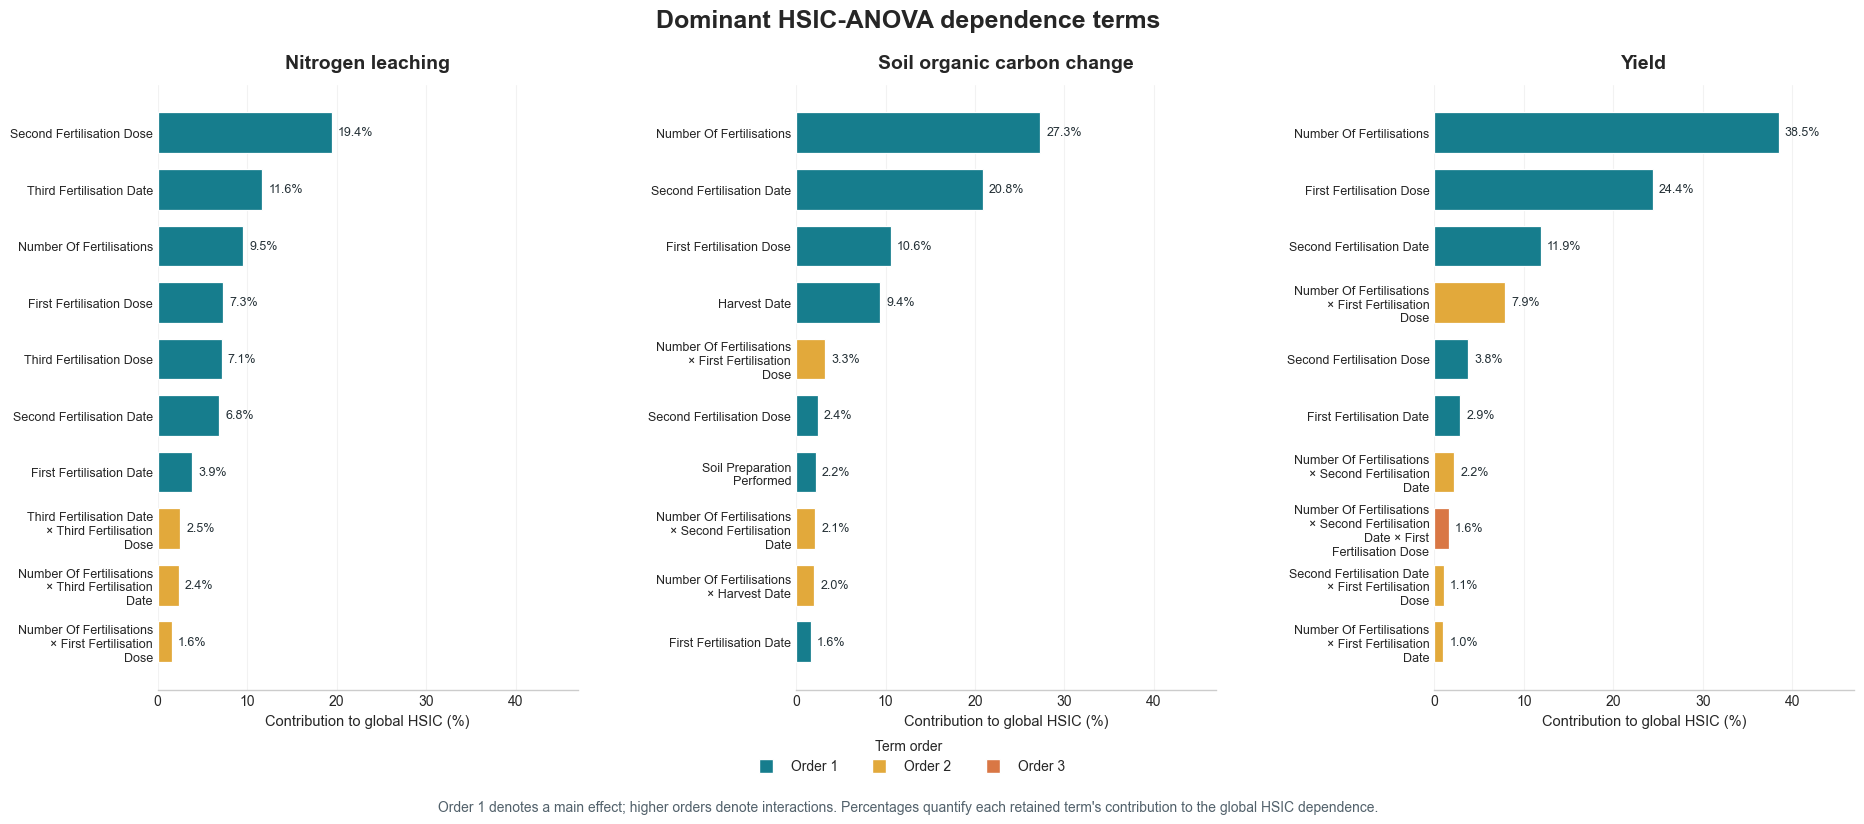

Figure saved to: /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/hsic_anova_decomposition/hsic_anova_top_terms_all_outputs.png
Table saved to: /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/hsic_anova_decomposition/hsic_anova_top_terms_all_outputs.csv


,output_label,order,term_label,global_var_pct
9,Nitrogen leaching,1,Second Fertilisation Dose,19.45
8,Nitrogen leaching,1,Third Fertilisation Date,11.64
7,Nitrogen leaching,1,Number Of Fertilisations,9.55
6,Nitrogen leaching,1,First Fertilisation Dose,7.28
5,Nitrogen leaching,1,Third Fertilisation Dose,7.13
4,Nitrogen leaching,1,Second Fertilisation Date,6.82
3,Nitrogen leaching,1,First Fertilisation Date,3.88
2,Nitrogen leaching,2,Third Fertilisation Date × Third Fertilisation...,2.52
1,Nitrogen leaching,2,Number Of Fertilisations × Third Fertilisation...,2.35
0,Nitrogen leaching,2,Number Of Fertilisations × First Fertilisation...,1.57


In [9]:
# =============================================================================
# HSIC-ANOVA: dominant dependence terms for all MAELIA outputs
# =============================================================================

import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

HSIC_TERMS_CSV = OUTPUT_DIR / "hsic_anova_terms_real_maelia.csv"
FIG_DIR = OUTPUT_DIR / "hsic_anova_decomposition"
FIG_DIR.mkdir(parents=True, exist_ok=True)

if "hsic_all" in globals() and not hsic_all.empty:
    hsic_terms = hsic_all.copy()
else:
    hsic_terms = pd.read_csv(HSIC_TERMS_CSV)

if hsic_terms.empty:
    raise ValueError("No HSIC-ANOVA terms are available. Run the HSIC computation first.")

if "global_var_pct" not in hsic_terms.columns and "contribution_hsic_globale_pct" in hsic_terms.columns:
    hsic_terms = hsic_terms.rename(
        columns={"contribution_hsic_globale_pct": "global_var_pct"}
    )
if "variables" not in hsic_terms.columns and "name" in hsic_terms.columns:
    hsic_terms["variables"] = hsic_terms["name"]

required_cols = {"sortie", "order", "variables", "global_var_pct"}
missing = required_cols - set(hsic_terms.columns)
if missing:
    raise ValueError(f"Missing HSIC columns: {sorted(missing)}")

outputs = [name for name in OUTPUT_COLS if name in set(hsic_terms["sortie"])]
if not outputs:
    outputs = list(hsic_terms["sortie"].dropna().unique())

TOP_N = 10
ORDER_COLORS = {
    1: "#167D8D",
    2: "#E2A93B",
    3: "#D97745",
    4: "#B94A48",
}

def display_feature_name(raw_name):
    return FEATURE_DISPLAY_NAMES.get(raw_name, raw_name).replace("_", " ")

def format_hsic_term(term, width=25):
    names = [display_feature_name(item.strip()) for item in str(term).split("&")]
    return textwrap.fill(" × ".join(names), width=width, break_long_words=False)

plot_tables = {}
for output in outputs:
    data = (
        hsic_terms.loc[hsic_terms["sortie"] == output]
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["global_var_pct"])
        .sort_values("global_var_pct", ascending=False)
        .head(TOP_N)
        .copy()
    )
    if data.empty:
        continue
    data["order"] = data["order"].astype(int)
    data["display_term"] = data["variables"].map(format_hsic_term)
    plot_tables[output] = data.sort_values("global_var_pct", ascending=True)

if not plot_tables:
    raise ValueError("No finite HSIC contribution could be plotted.")

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(
    1,
    len(plot_tables),
    figsize=(19.5, 8.4),
    squeeze=False,
)
axes = axes.ravel()

global_max = max(
    float(data["global_var_pct"].max())
    for data in plot_tables.values()
)
xmax = max(1.0, global_max * 1.22)

for ax, (output, data) in zip(axes, plot_tables.items()):
    colors = data["order"].map(lambda order: ORDER_COLORS.get(order, "#66788A"))
    bars = ax.barh(
        data["display_term"],
        data["global_var_pct"],
        color=colors,
        edgecolor="white",
        linewidth=0.9,
        height=0.72,
    )

    ax.set_xlim(0, xmax)
    ax.set_title(
        OUTPUT_DISPLAY_NAMES.get(output, output),
        fontsize=14,
        fontweight="bold",
        pad=12,
    )
    ax.set_xlabel("Contribution to global HSIC (%)", fontsize=10.5)
    ax.tick_params(axis="y", labelsize=9)
    ax.grid(axis="x", alpha=0.24)
    ax.grid(axis="y", visible=False)

    for bar, value in zip(bars, data["global_var_pct"]):
        ax.text(
            min(value + xmax * 0.015, xmax * 0.97),
            bar.get_y() + bar.get_height() / 2,
            f"{value:.1f}%",
            va="center",
            ha="left",
            fontsize=9,
            color="#263238",
        )

    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)

present_orders = sorted(
    {
        int(order)
        for data in plot_tables.values()
        for order in data["order"].unique()
    }
)
legend_handles = [
    Line2D(
        [0],
        [0],
        marker="s",
        linestyle="",
        markersize=10,
        markerfacecolor=ORDER_COLORS.get(order, "#66788A"),
        markeredgecolor="white",
        label=f"Order {order}",
    )
    for order in present_orders
]

fig.suptitle(
    "Dominant HSIC-ANOVA dependence terms",
    fontsize=18,
    fontweight="bold",
    y=0.97,
)
fig.legend(
    handles=legend_handles,
    title="Term order",
    loc="lower center",
    bbox_to_anchor=(0.5, 0.045),
    ncol=max(1, len(legend_handles)),
    frameon=False,
)
fig.text(
    0.5,
    0.012,
    "Order 1 denotes a main effect; higher orders denote interactions. "
    "Percentages quantify each retained term's contribution to the global HSIC dependence.",
    ha="center",
    va="bottom",
    fontsize=10,
    color="#52616B",
)
fig.subplots_adjust(left=0.115, right=0.985, top=0.88, bottom=0.16, wspace=0.52)

fig_path = FIG_DIR / "hsic_anova_top_terms_all_outputs.png"
fig.savefig(fig_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

combined_top_terms = pd.concat(
    [
        data.assign(
            output_label=OUTPUT_DISPLAY_NAMES.get(output, output),
            term_label=data["variables"].map(
                lambda value: " × ".join(
                    display_feature_name(item.strip())
                    for item in str(value).split("&")
                )
            ),
        )
        for output, data in plot_tables.items()
    ],
    ignore_index=True,
)
table_path = FIG_DIR / "hsic_anova_top_terms_all_outputs.csv"
combined_top_terms.to_csv(table_path, index=False)

print(f"Figure saved to: {fig_path}")
print(f"Table saved to: {table_path}")
display(
    combined_top_terms[
        ["output_label", "order", "term_label", "global_var_pct"]
    ]
    .sort_values(["output_label", "global_var_pct"], ascending=[True, False])
    .round({"global_var_pct": 2})
)


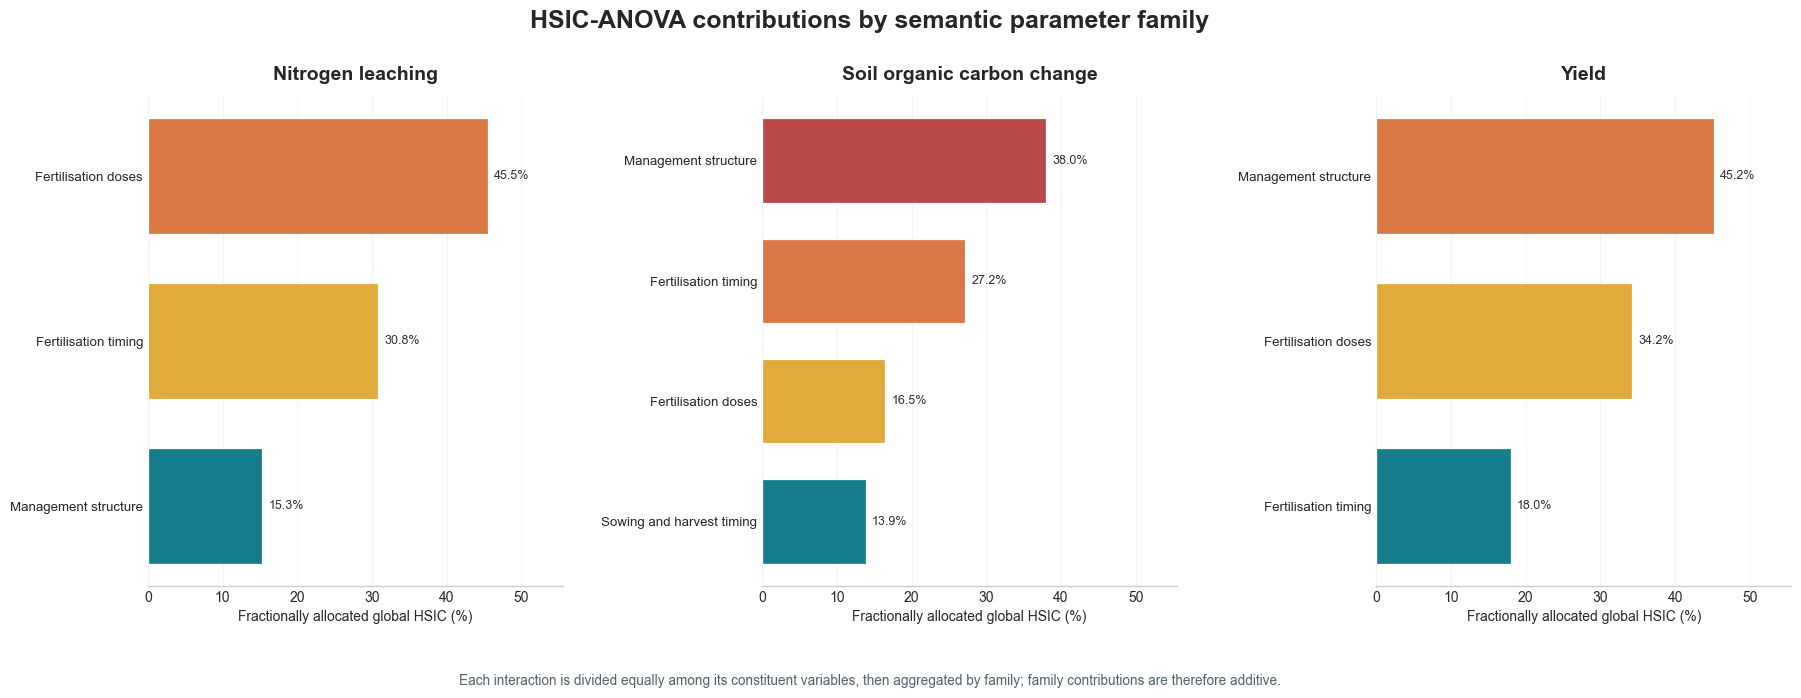

Figure saved to: /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/hsic_anova_semantic_groups/hsic_anova_semantic_families.png


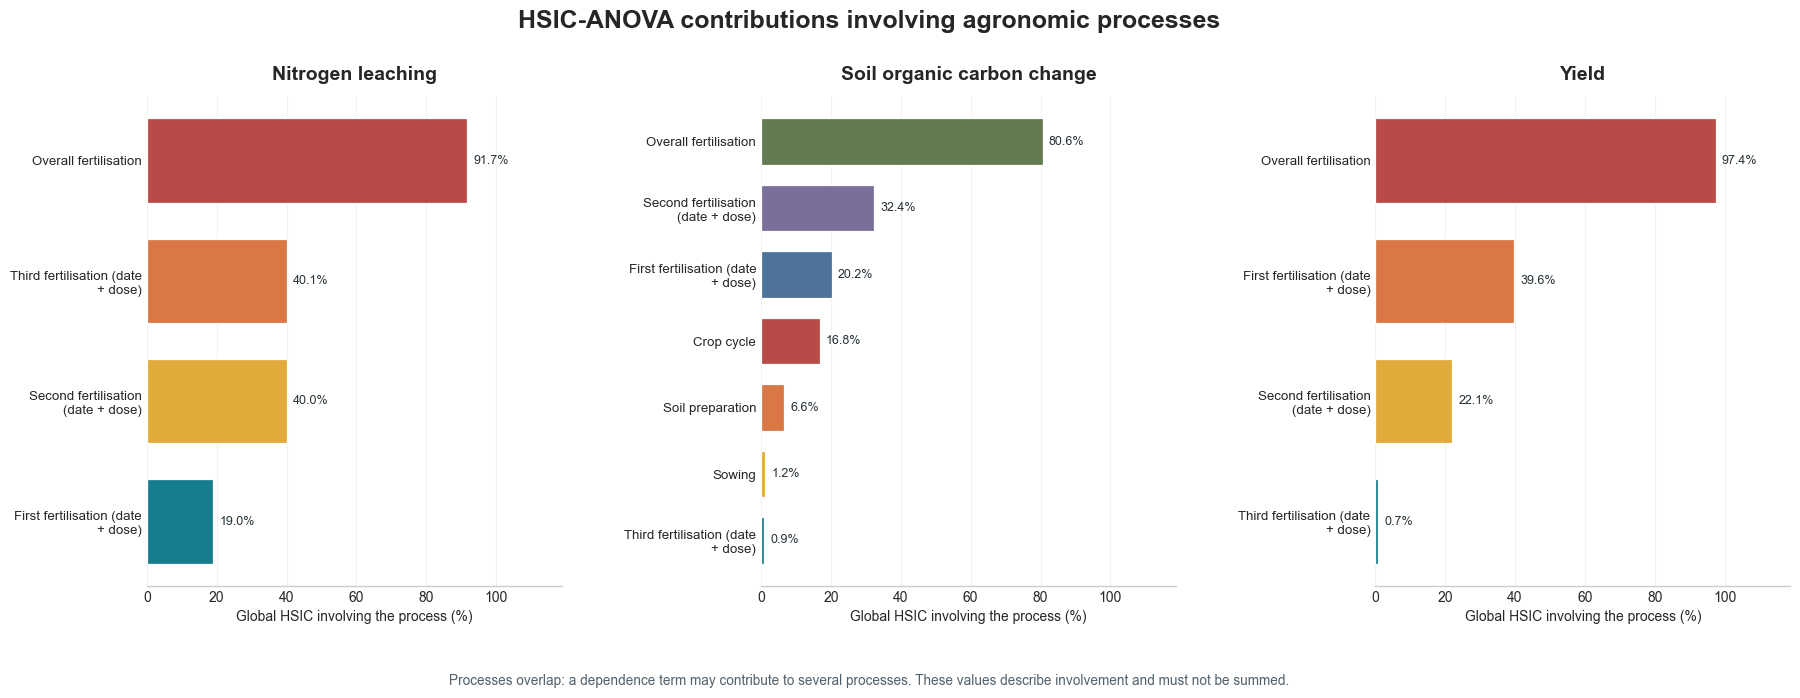

Figure saved to: /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/hsic_anova_semantic_groups/hsic_anova_agronomic_processes.png
Tables saved in: /Users/benjamin/files/Repositories/Sensitivity_analysis_MAELIA/analysis/hsic_anova_results/hsic_anova_semantic_groups


,output,semantic_family,hsic_contribution_pct
0,N_lixi,Fertilisation doses,45.54
1,N_lixi,Fertilisation timing,30.85
2,N_lixi,Management structure,15.34
5,dCorg,Management structure,38.01
4,dCorg,Fertilisation timing,27.18
3,dCorg,Fertilisation doses,16.51
6,dCorg,Sowing and harvest timing,13.89
9,rdt,Management structure,45.19
7,rdt,Fertilisation doses,34.20
8,rdt,Fertilisation timing,18.01


,output,agronomic_process,hsic_contribution_pct
1,N_lixi,Overall fertilisation,91.73
3,N_lixi,Third fertilisation (date + dose),40.07
2,N_lixi,Second fertilisation (date + dose),40.04
0,N_lixi,First fertilisation (date + dose),18.99
6,dCorg,Overall fertilisation,80.63
7,dCorg,Second fertilisation (date + dose),32.42
5,dCorg,First fertilisation (date + dose),20.16
4,dCorg,Crop cycle,16.82
8,dCorg,Soil preparation,6.58
9,dCorg,Sowing,1.24


In [10]:
# =============================================================================
# HSIC-ANOVA aggregation by semantic families and agronomic processes
# =============================================================================

import re
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HSIC_TERMS_CSV = OUTPUT_DIR / "hsic_anova_terms_real_maelia.csv"
GROUP_DIR = OUTPUT_DIR / "hsic_anova_semantic_groups"
GROUP_DIR.mkdir(parents=True, exist_ok=True)

if "hsic_all" in globals() and not hsic_all.empty:
    hsic_terms = hsic_all.copy()
else:
    hsic_terms = pd.read_csv(HSIC_TERMS_CSV)

if hsic_terms.empty:
    raise ValueError("No HSIC-ANOVA terms are available. Run the HSIC computation first.")

hsic_terms["global_var_pct"] = pd.to_numeric(
    hsic_terms["global_var_pct"], errors="coerce"
).fillna(0.0)

def parse_hsic_variables(value):
    text = str(value)
    found = []
    for feature in AGRI_FEATURES:
        pattern = rf"(?<![A-Za-z0-9_]){re.escape(feature)}(?![A-Za-z0-9_])"
        if re.search(pattern, text):
            found.append(feature)
    return found

hsic_terms["variable_list"] = hsic_terms["variables"].apply(parse_hsic_variables)
hsic_terms = hsic_terms[hsic_terms["variable_list"].map(len) > 0].copy()

# Additive semantic families: each HSIC term is divided equally among its
# constituent variables before aggregation, which prevents double counting.
SEMANTIC_GROUPS = {
    "Management structure": {
        "n_ferti", "nb_prepa",
    },
    "Sowing and harvest timing": {
        "Date_Semis", "Date_Recolte", "Delta_PREPA_Semis",
    },
    "Fertilisation timing": {
        "Date_F1", "Date_F2", "Date_F3",
    },
    "Fertilisation doses": {
        "Dose_F1", "Dose_F2", "Dose_F3",
    },
    "Operation depths": {
        "Profondeur_Semis", "Profondeur_Prepa_1", "Profondeur_Prepa_2",
    },
}

variable_to_semantic_group = {
    variable: group
    for group, variables in SEMANTIC_GROUPS.items()
    for variable in variables
}

semantic_rows = []
for _, row in hsic_terms.iterrows():
    variables = row["variable_list"]
    if not variables:
        continue
    share_per_variable = row["global_var_pct"] / len(variables)
    for variable in variables:
        semantic_rows.append({
            "output": row["sortie"],
            "semantic_family": variable_to_semantic_group.get(variable, "Other"),
            "variable": variable,
            "hsic_contribution_pct": share_per_variable,
        })

semantic_df = pd.DataFrame(semantic_rows)
semantic_summary = (
    semantic_df
    .groupby(["output", "semantic_family"], as_index=False)["hsic_contribution_pct"]
    .sum()
    .sort_values(["output", "hsic_contribution_pct"], ascending=[True, False])
)
semantic_summary.to_csv(
    GROUP_DIR / "hsic_anova_semantic_families.csv",
    index=False,
)

# Overlapping agronomic processes answer process-level questions. Because one
# HSIC term may involve several processes, these contributions are non-additive.
AGRONOMIC_PROCESSES = {
    "Soil preparation": {
        "nb_prepa", "Delta_PREPA_Semis",
        "Profondeur_Prepa_1", "Profondeur_Prepa_2",
    },
    "Sowing": {
        "Date_Semis", "Profondeur_Semis",
    },
    "Crop cycle": {
        "Date_Semis", "Date_Recolte",
    },
    "Overall fertilisation": {
        "n_ferti", "Date_F1", "Date_F2", "Date_F3",
        "Dose_F1", "Dose_F2", "Dose_F3",
    },
    "First fertilisation (date + dose)": {
        "Date_F1", "Dose_F1",
    },
    "Second fertilisation (date + dose)": {
        "Date_F2", "Dose_F2",
    },
    "Third fertilisation (date + dose)": {
        "Date_F3", "Dose_F3",
    },
}

process_rows = []
for _, row in hsic_terms.iterrows():
    variables = set(row["variable_list"])
    for process_name, process_variables in AGRONOMIC_PROCESSES.items():
        overlap = variables.intersection(process_variables)
        if overlap:
            process_rows.append({
                "output": row["sortie"],
                "agronomic_process": process_name,
                "involved_variables": ", ".join(sorted(overlap)),
                "hsic_term": row["variables"],
                "hsic_contribution_pct": row["global_var_pct"],
            })

process_df = pd.DataFrame(process_rows)
process_summary = (
    process_df
    .groupby(["output", "agronomic_process"], as_index=False)["hsic_contribution_pct"]
    .sum()
    .sort_values(["output", "hsic_contribution_pct"], ascending=[True, False])
)
process_summary.to_csv(
    GROUP_DIR / "hsic_anova_agronomic_processes.csv",
    index=False,
)

plt.style.use("seaborn-v0_8-whitegrid")
PANEL_COLORS = ["#167D8D", "#E2A93B", "#D97745", "#B94A48", "#4D7399", "#7A6F9B", "#637A53"]

def wrapped_label(value, width=25):
    return textwrap.fill(str(value), width=width, break_long_words=False)

def plot_group_summary(summary, group_col, value_col, title, fig_name, xlabel, note):
    outputs = [name for name in OUTPUT_COLS if name in set(summary["output"])]
    if not outputs:
        outputs = list(summary["output"].dropna().unique())

    datasets = {
        output: (
            summary.loc[summary["output"] == output]
            .sort_values(value_col, ascending=True)
            .tail(10)
            .copy()
        )
        for output in outputs
    }
    global_max = max(
        float(data[value_col].max())
        for data in datasets.values()
        if not data.empty
    )
    xmax = max(1.0, global_max * 1.22)

    fig, axes = plt.subplots(
        1,
        len(outputs),
        figsize=(19.0, 7.2),
        squeeze=False,
    )
    axes = axes.ravel()

    for ax, output in zip(axes, outputs):
        data = datasets[output]
        labels = data[group_col].map(wrapped_label)
        colors = PANEL_COLORS[:len(data)]
        bars = ax.barh(
            labels,
            data[value_col],
            color=colors,
            edgecolor="white",
            linewidth=0.9,
            height=0.7,
        )

        ax.set_xlim(0, xmax)
        ax.set_title(
            OUTPUT_DISPLAY_NAMES.get(output, output),
            fontsize=14,
            fontweight="bold",
            pad=12,
        )
        ax.set_xlabel(xlabel, fontsize=10)
        ax.tick_params(axis="y", labelsize=9.5)
        ax.grid(axis="x", alpha=0.24)
        ax.grid(axis="y", visible=False)

        for bar, value in zip(bars, data[value_col]):
            ax.text(
                min(value + xmax * 0.015, xmax * 0.97),
                bar.get_y() + bar.get_height() / 2,
                f"{value:.1f}%",
                va="center",
                ha="left",
                fontsize=9,
                color="#263238",
            )

        for spine in ("top", "right", "left"):
            ax.spines[spine].set_visible(False)

    fig.suptitle(title, fontsize=18, fontweight="bold", y=0.96)
    fig.text(
        0.5,
        0.018,
        note,
        ha="center",
        va="bottom",
        fontsize=9.8,
        color="#52616B",
    )
    fig.subplots_adjust(left=0.12, right=0.985, top=0.84, bottom=0.16, wspace=0.48)

    fig_path = GROUP_DIR / fig_name
    fig.savefig(fig_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Figure saved to: {fig_path}")

plot_group_summary(
    semantic_summary,
    group_col="semantic_family",
    value_col="hsic_contribution_pct",
    title="HSIC-ANOVA contributions by semantic parameter family",
    fig_name="hsic_anova_semantic_families.png",
    xlabel="Fractionally allocated global HSIC (%)",
    note=(
        "Each interaction is divided equally among its constituent variables, "
        "then aggregated by family; family contributions are therefore additive."
    ),
)

plot_group_summary(
    process_summary,
    group_col="agronomic_process",
    value_col="hsic_contribution_pct",
    title="HSIC-ANOVA contributions involving agronomic processes",
    fig_name="hsic_anova_agronomic_processes.png",
    xlabel="Global HSIC involving the process (%)",
    note=(
        "Processes overlap: a dependence term may contribute to several processes. "
        "These values describe involvement and must not be summed."
    ),
)

print(f"Tables saved in: {GROUP_DIR}")
display(semantic_summary.round(2))
display(process_summary.round(2))
